In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


**Q1: Load the dataset into a Pandas DataFrame and display the first 10 rows of the dataset.**

In [ ]:
df=pd.read_csv("flipkart.csv")
df.head(10)

,Order ID,Product Name,Category,Price (INR),Quantity Sold,Total Sales (INR),Order Date,Payment Method,Customer Rating,Month,Year,Profit (INR),Discount %,Customer Segment,Region
0,ORD00001,Educational Book,Books,49069.56,2,98139.12,2024-09-12,Debit Card,3.5,September,2024,19627.824,11,Online,West
1,ORD00002,Jeans,Clothing,12755.85,4,51023.40,2024-12-18,UPI,3.9,December,2024,10204.680,24,Wholesale,North
2,ORD00003,Face Cream,Beauty,11092.19,4,44368.76,2024-05-18,Debit Card,4.4,May,2024,8873.752,19,Online,South
3,ORD00004,Smartwatch,Electronics,32657.81,1,32657.81,2024-11-08,Debit Card,3.2,November,2024,6531.562,15,Online,North
4,ORD00005,Cookware Set,Home & Kitchen,26590.08,3,79770.24,2024-12-27,UPI,3.1,December,2024,15954.048,12,Retail,North
5,ORD00006,Mixer Grinder,Home & Kitchen,10475.03,2,20950.06,2024-10-22,Wallet,1.7,October,2024,4190.012,25,Wholesale,North
6,ORD00007,Sneakers,Clothing,38647.72,3,115943.16,2024-07-04,Wallet,2.0,July,2024,23188.632,11,Wholesale,North
7,ORD00008,Table Lamp,Home & Kitchen,24818.59,3,74455.77,2024-12-27,Debit Card,2.4,December,2024,14891.154,30,Wholesale,South
8,ORD00009,Jacket,Clothing,1987.39,2,3974.78,2025-01-18,Debit Card,2.6,January,2025,794.956,23,Online,North
9,ORD00010,Tablet,Electronics,26876.51,2,53753.02,2024-03-14,Debit Card,4.0,March,2024,10750.604,27,Online,North


**Q2. Find the following details of the dataset:**

**a) Determine the total number of rows and columns present in the dataset.**

**b) Display the data type of each column in the dataset.**

In [ ]:
print("Rows and Columns:", df.shape)#question a)
print()
print(df.dtypes)#question b

Rows and Columns: (1000, 15)

Order ID              object
Product Name          object
Category              object
Price (INR)          float64
Quantity Sold          int64
Total Sales (INR)    float64
Order Date            object
Payment Method        object
Customer Rating      float64
Month                 object
Year                   int64
Profit (INR)         float64
Discount %             int64
Customer Segment      object
Region                object
dtype: object


**Q3. Display the names of all columns present in the dataset.**

In [ ]:
print(df.columns)

Index(['Order ID', 'Product Name', 'Category', 'Price (INR)', 'Quantity Sold',
       'Total Sales (INR)', 'Order Date', 'Payment Method', 'Customer Rating',
       'Month', 'Year', 'Profit (INR)', 'Discount %', 'Customer Segment',
       'Region'],
      dtype='object')


**Q4. Find the number of missing values present in each column of the dataset.**

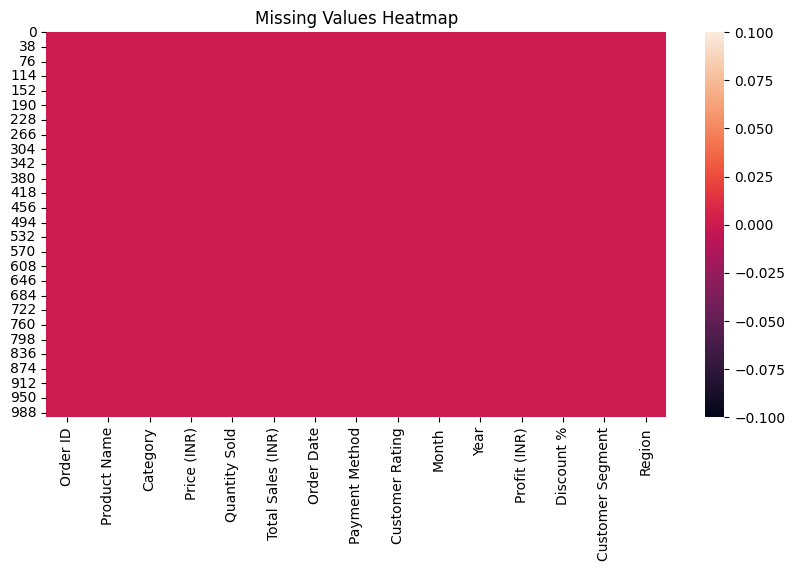

In [ ]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull())
plt.title("Missing Values Heatmap")
plt.show()

**Q5. Analyze the distribution of orders across different categories and visualize the results using:**

a) A Bar Chart to show the number of orders in each category.

b) A Pie Chart to represent the percentage share of orders by category.

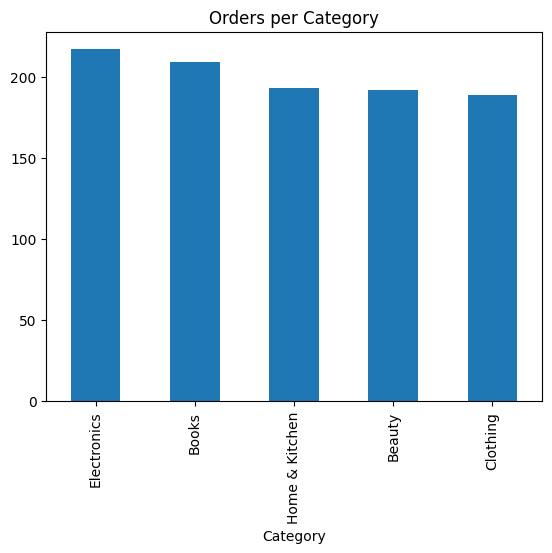

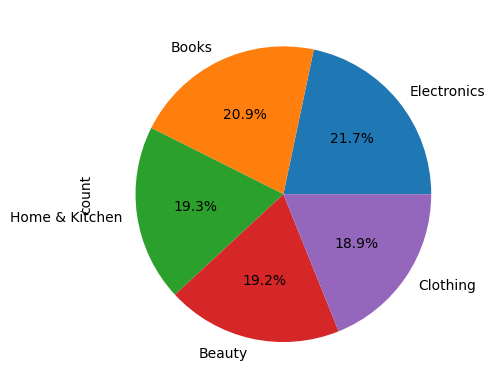

In [ ]:
orders = df['Category'].value_counts()
#Solution a)
orders.plot(kind='bar')
plt.title("Orders per Category")
plt.show()
print()
#Solution b)
orders.plot(kind='pie', autopct='%1.1f%%')
plt.show()

**Q6. Identify the Top 10 Products based on Total Sales and visualize the results using a Horizontal Bar Chart.**

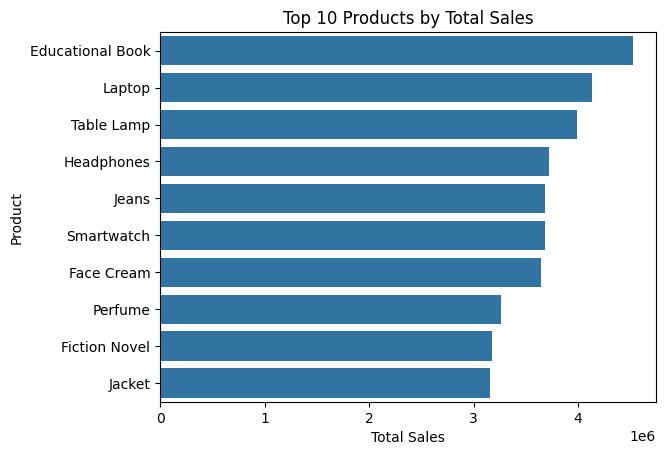

In [ ]:
top10 = df.groupby('Product Name')['Total Sales (INR)'].sum().nlargest(10)

sns.barplot(x=top10.values, y=top10.index)
plt.title("Top 10 Products by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.show()

**Q7 Compare the number of orders across all payment methods and highlight the Cash on Delivery (COD) payment method using a Bar Chart.**

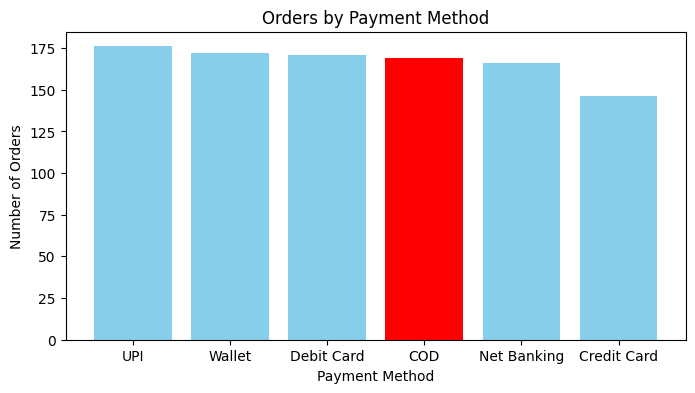

In [ ]:
payment_counts = df['Payment Method'].value_counts()
colors = ['red' if method == 'COD' else 'skyblue'
          for method in payment_counts.index]
plt.figure(figsize=(8,4))
plt.bar(payment_counts.index, payment_counts.values, color=colors)
plt.title("Orders by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.show()

**Q8 Analyze the number of orders placed by each Customer Segment and visualize the distribution using a Count Plot.**

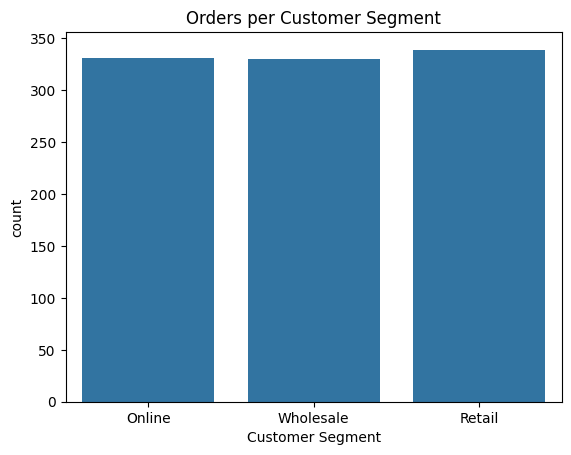

In [ ]:
sns.countplot(data=df, x='Customer Segment')
plt.title("Orders per Customer Segment")
plt.show()

**Q9. Calculate the Average Price, Average Sales, and Average Profit for each Category and visualize the results using three separate Bar Charts.**

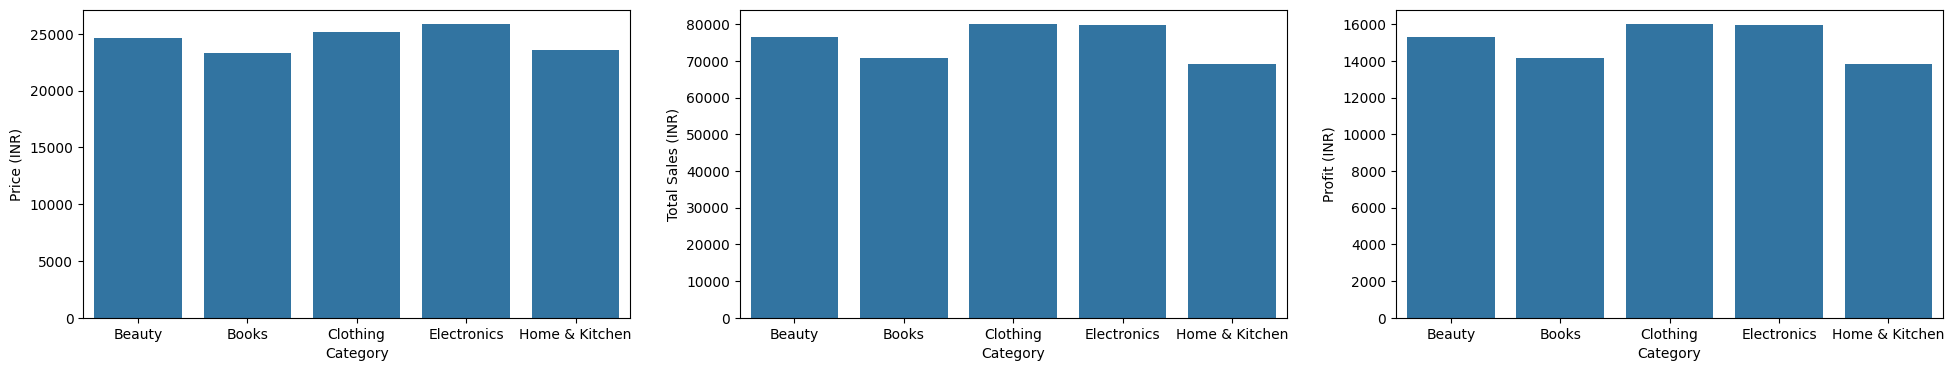

In [ ]:
avg = df.groupby('Category')[['Price (INR)','Total Sales (INR)','Profit (INR)']].mean().reset_index()
fig, ax = plt.subplots(1,3, figsize=(24,4))
sns.barplot(data=avg, x='Category', y='Price (INR)', ax=ax[0])
sns.barplot(data=avg, x='Category', y='Total Sales (INR)', ax=ax[1])
sns.barplot(data=avg, x='Category', y='Profit (INR)', ax=ax[2])
plt.show()

**Q10. Identify the Region with the Highest Total Sales and visualize the total sales across all regions using:**

a) A Bar Chart (Seaborn)

b) A Pie Chart (Matplotlib)

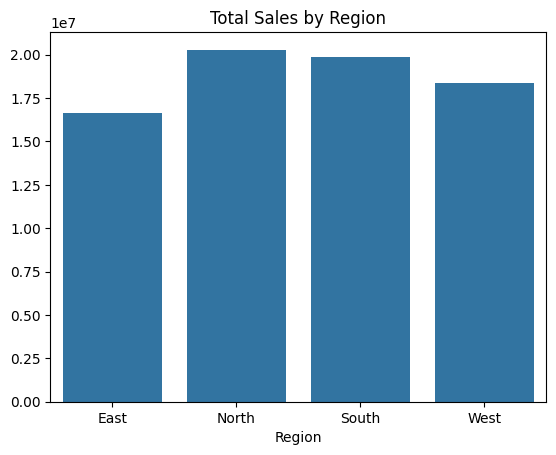

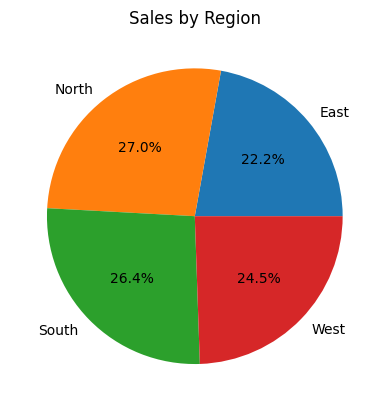

In [ ]:
region_sales = df.groupby('Region')['Total Sales (INR)'].sum()
sns.barplot(x=region_sales.index, y=region_sales.values)
plt.title("Total Sales by Region")
plt.show()
print()
plt.figure()
plt.pie(region_sales, labels=region_sales.index, autopct='%1.1f%%')
plt.title("Sales by Region")
plt.show()

**Q11. Find the Month with the Maximum Number of Orders and visualize the monthly order trend using a Line Chart with a Filled Area**.

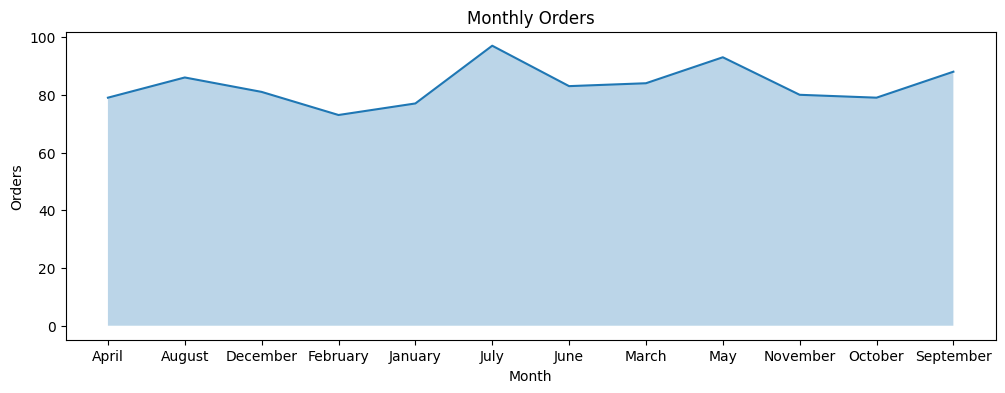

In [ ]:
monthly_orders = df['Month'].value_counts().sort_index()
plt.figure(figsize=(12,4))
sns.lineplot(x=monthly_orders.index, y=monthly_orders.values)
plt.fill_between(monthly_orders.index, monthly_orders.values, alpha=0.3)
plt.title("Monthly Orders")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.show()